In [1]:
import pandas as pd
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import plot_importance
from sklearn.inspection import PartialDependenceDisplay
import seaborn as sns
import shap
from scipy.stats import spearmanr, pearsonr
import os

c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -----------------------------
# 1. Load data
# -----------------------------
csv_candidates = [
    "ml_panel_noaa_x_fda_recalls_x_cost.csv",
    "ml_panel_noaa_x_fda_recalls_x_cost(1).csv",
]
csv_path = next((p for p in csv_candidates if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(f"Could not find any of: {csv_candidates}")

df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["state_abbr", "date"]).reset_index(drop=True)

target = "log_pathogen_cost_index"
raw_target = "pathogen_weighted_cost_index"

# Event indicator
df["event_flag"] = (df[raw_target] > 0).astype(int)

# -----------------------------
# 2. Feature engineering (weather only)
# -----------------------------
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Rolling climate baselines by state
df["temp_roll12"] = df.groupby("state_abbr")["temp_f"].transform(
    lambda x: x.rolling(12, min_periods=3).mean()
)
df["pcpn_roll12"] = df.groupby("state_abbr")["pcpn_in"].transform(
    lambda x: x.rolling(12, min_periods=3).mean()
)

# Climate anomalies
df["temp_dev"] = df["temp_f"] - df["temp_roll12"]
df["pcpn_dev"] = df["pcpn_in"] - df["pcpn_roll12"]

# Interactions
df["temp_x_pcpn"] = df["temp_f"] * df["pcpn_in"]
df["temp_dev_x_pcpn_dev"] = df["temp_dev"] * df["pcpn_dev"]

# Optional anomaly interaction
if "temp_anom" in df.columns and "pcpn_anom" in df.columns:
    df["temp_anom_x_pcpn_anom"] = df["temp_anom"] * df["pcpn_anom"]

# -----------------------------
# 3. Train/test split
# -----------------------------
train_df = df[df["year"].between(2012, 2024)].copy()
test_df  = df[df["year"] >= 2025].copy()

# Fill remaining NaNs from lags/rolls
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# -----------------------------
# 4. Features for classifier
# -----------------------------
drop_cols = [
    target,
    raw_target,
    "date",
    "year",
    "state_abbr",
    "recall_count",
    "pathogen_recalls",
    "class_I",
    "class_II",
    "class_III",
    "event_flag"
]

feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train_cls = train_df["event_flag"]
y_test_cls = test_df["event_flag"]

# -----------------------------
# 5. Full weather-only classifier
# -----------------------------
pos = y_train_cls.sum()
neg = len(y_train_cls) - pos
scale_pos_weight = neg / pos if pos > 0 else 1.0

clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight
)

clf_param_grid = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=6)

clf_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=clf_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=tscv,
    verbose=1,
    n_jobs=1,
    random_state=123,
    error_score="raise"
)

clf_search.fit(X_train, y_train_cls)
best_clf = clf_search.best_estimator_

test_event_prob = best_clf.predict_proba(X_test)[:, 1]
full_auc = roc_auc_score(y_test_cls, test_event_prob)
full_ap = average_precision_score(y_test_cls, test_event_prob)

print("Best full classifier params:")
print(clf_search.best_params_)
print("Full weather-only classifier")
print("Feature count:", len(feature_cols))
print("Train event rate:", y_train_cls.mean())
print("Test event rate:", y_test_cls.mean())
print("Test ROC AUC:", full_auc)
print("Test Average Precision:", full_ap)


Fitting 6 folds for each of 30 candidates, totalling 180 fits


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\xgboost\core.py:751: UserWarning: [19:53:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best full classifier params:
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}
Full weather-only classifier
Feature count: 18
Train event rate: 0.1497906855049712
Test event rate: 0.06717687074829932
Test ROC AUC: 0.8116612625918789
Test Average Precision: 0.3401515263853239


In [3]:
# -----------------------------
# 6. Reduce to top 10 weather features and retrain
# -----------------------------
importances = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_features = importances.head(10).index.tolist()
print("Top 10 features used for retraining:")
print(top_features)

X_train_small = X_train[top_features]
X_test_small = X_test[top_features]

clf_small = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight,
    **clf_search.best_params_
)

clf_small.fit(X_train_small, y_train_cls)
test_event_prob_small = clf_small.predict_proba(X_test_small)[:, 1]

auc_small = roc_auc_score(y_test_cls, test_event_prob_small)
ap_small = average_precision_score(y_test_cls, test_event_prob_small)

print("===== Top-10 Feature Model Performance =====")
print("ROC AUC:", auc_small)
print("Average Precision:", ap_small)

print("===== Comparison =====")
print("Full model AUC:", full_auc)
print("Top-10 model AUC:", auc_small)
print("Full model AP:", full_ap)
print("Top-10 model AP:", ap_small)


Top 10 features used for retraining:
['pcpn_roll12', 'temp_roll12', 'pcpn_in_roll3', 'month', 'temp_f_roll3', 'temp_dev', 'temp_f_lag1', 'temp_f', 'pcpn_dev', 'pcpn_anom']
===== Top-10 Feature Model Performance =====
ROC AUC: 0.8357315117178035
Average Precision: 0.37856970103662235
===== Comparison =====
Full model AUC: 0.8116612625918789
Top-10 model AUC: 0.8357315117178035
Full model AP: 0.3401515263853239
Top-10 model AP: 0.37856970103662235


===== Logistic / Classifier Performance (TOP 10 FEATURES) =====
Test ROC AUC: 0.8357315117178035
Test Average Precision: 0.37856970103662235
=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

           0       0.97      0.87      0.91      1097
           1       0.24      0.58      0.34        79

    accuracy                           0.85      1176
   macro avg       0.60      0.72      0.63      1176
weighted avg       0.92      0.85      0.88      1176

Confusion Matrix:
[[951 146]
 [ 33  46]]
=== Classification Report (threshold=0.7) ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1097
           1       0.51      0.28      0.36        79

    accuracy                           0.93      1176
   macro avg       0.73      0.63      0.66      1176
weighted avg       0.92      0.93      0.92      1176

Confusion Matrix:
[[1076   21]
 [  57   22]]
=== Classification Report (

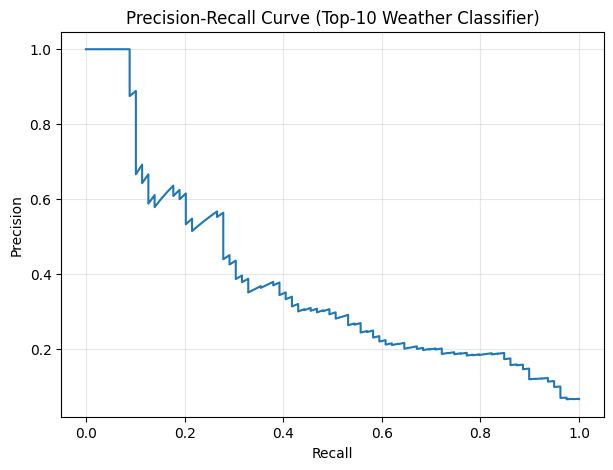

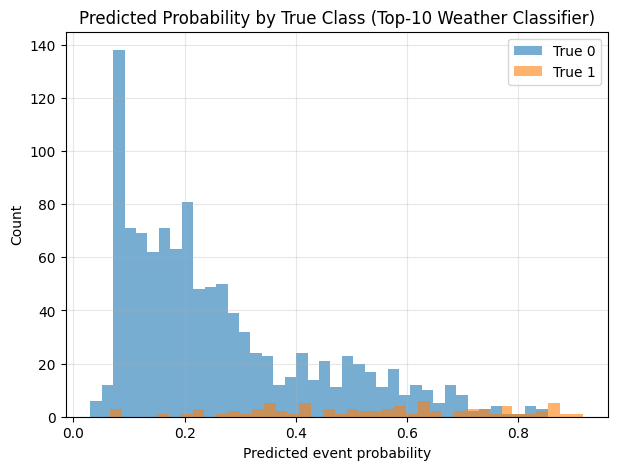

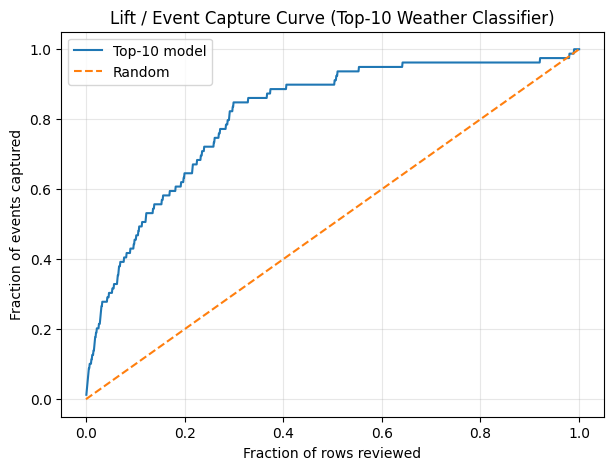

In [4]:
# -----------------------------
# 7. Test-set metrics for TOP-10 classifier only
# -----------------------------
clf_auc = roc_auc_score(y_test_cls, test_event_prob_small)
clf_ap = average_precision_score(y_test_cls, test_event_prob_small)

print("===== Logistic / Classifier Performance (TOP 10 FEATURES) =====")
print("Test ROC AUC:", clf_auc)
print("Test Average Precision:", clf_ap)

for thr in [0.5, 0.7, 0.85]:
    y_pred_thr = (test_event_prob_small >= thr).astype(int)
    print(f"=== Classification Report (threshold={thr}) ===")
    print(classification_report(y_test_cls, y_pred_thr))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_cls, y_pred_thr))

precision, recall, thresholds = precision_recall_curve(y_test_cls, test_event_prob_small)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_thr_cls = thresholds[best_idx]

print("Best threshold by F1:", best_thr_cls)
print("Precision at best F1:", precision[best_idx])
print("Recall at best F1:", recall[best_idx])
print("F1 at best threshold:", f1_scores[best_idx])

# Visual 1: Precision-Recall Curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Top-10 Weather Classifier)")
plt.grid(True, alpha=0.3)
plt.show()

# Visual 2: Probability histograms by true class
plt.figure(figsize=(7, 5))
plt.hist(test_event_prob_small[y_test_cls == 0], bins=40, alpha=0.6, label="True 0")
plt.hist(test_event_prob_small[y_test_cls == 1], bins=40, alpha=0.6, label="True 1")
plt.xlabel("Predicted event probability")
plt.ylabel("Count")
plt.title("Predicted Probability by True Class (Top-10 Weather Classifier)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visual 3: Lift / capture curve
lift_df = test_df.copy()
lift_df["prob_event_top10"] = test_event_prob_small
lift_df = lift_df.sort_values("prob_event_top10", ascending=False).reset_index(drop=True)
lift_df["cum_events"] = lift_df["event_flag"].cumsum()
total_events = lift_df["event_flag"].sum()
lift_df["cum_event_capture"] = lift_df["cum_events"] / total_events
lift_df["pct_rows_seen"] = (np.arange(len(lift_df)) + 1) / len(lift_df)

plt.figure(figsize=(7, 5))
plt.plot(lift_df["pct_rows_seen"], lift_df["cum_event_capture"], label="Top-10 model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("Fraction of rows reviewed")
plt.ylabel("Fraction of events captured")
plt.title("Lift / Event Capture Curve (Top-10 Weather Classifier)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


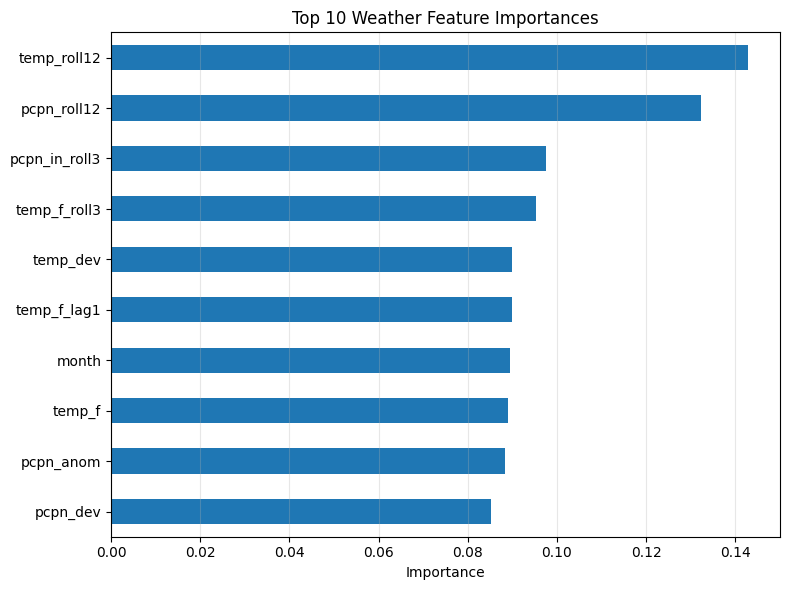

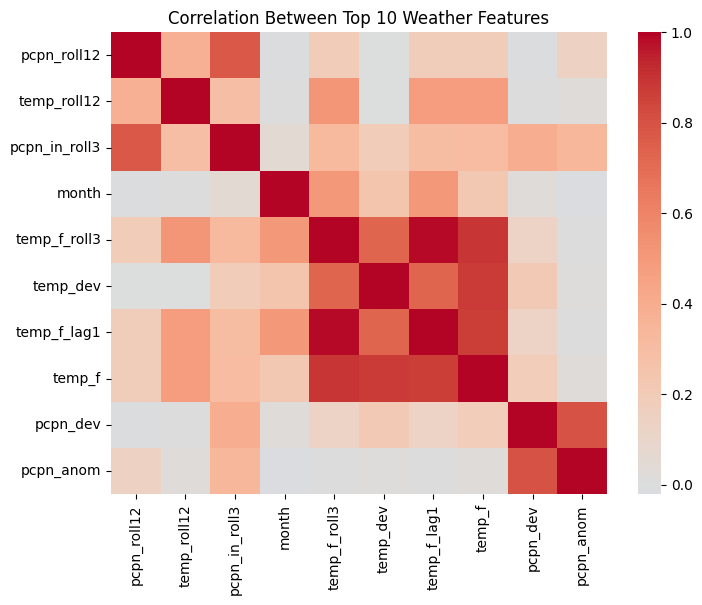

Top-10 classifier feature importances:
temp_roll12      0.142879
pcpn_roll12      0.132353
pcpn_in_roll3    0.097449
temp_f_roll3     0.095330
temp_dev         0.090036
temp_f_lag1      0.089842
month            0.089491
temp_f           0.089087
pcpn_anom        0.088415
pcpn_dev         0.085118
dtype: float32


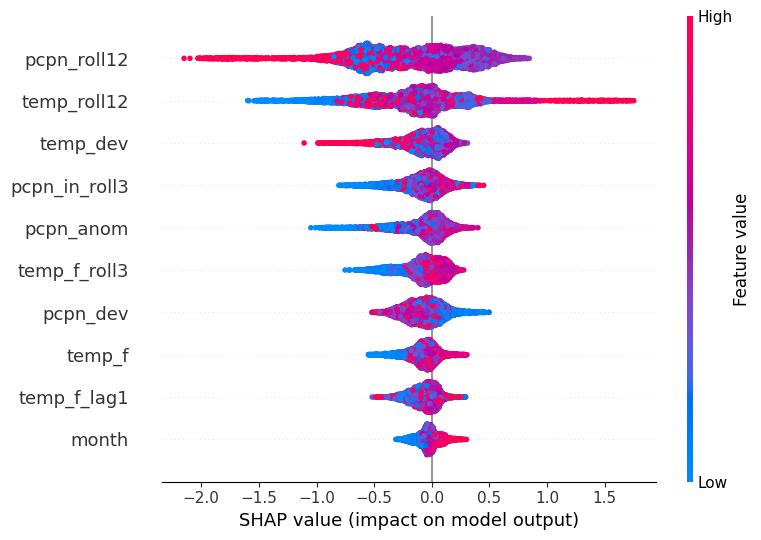

In [5]:
# -----------------------------
# 8. Visuals for the TOP-10 weather features only
# -----------------------------
importances_small = pd.Series(clf_small.feature_importances_, index=top_features).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_small.plot(kind="barh")
plt.title("Top 10 Weather Feature Importances")
plt.xlabel("Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

corr = train_df[top_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Between Top 10 Weather Features")
plt.show()

print("Top-10 classifier feature importances:")
print(importances_small.sort_values(ascending=False))

# SHAP summary for the top-10 model
try:
    explainer = shap.Explainer(clf_small)
    shap_values = explainer(X_train_small)
    shap.summary_plot(shap_values, X_train_small)
except Exception as e:
    print("SHAP summary skipped due to error:", e)

In [6]:
# -----------------------------
# 9. 2nd stage: WEATHER-ONLY severity model using TOP-10 features only
# -----------------------------
y_train_reg = train_df[target]
y_test_reg = test_df[target]

train_events_only = train_df[train_df["event_flag"] == 1].copy()
test_events_only = test_df[test_df["event_flag"] == 1].copy()

X_train_reg = train_events_only[top_features]
y_train_reg_events = train_events_only[target]

X_test_reg = test_events_only[top_features]
y_test_reg_events = test_events_only[target]

reg = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=123
)

reg_param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

tscv_reg = TimeSeriesSplit(n_splits=6)

reg_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=reg_param_grid,
    n_iter=30,
    scoring="r2",
    cv=tscv_reg,
    verbose=1,
    n_jobs=1,
    random_state=123,
    error_score="raise"
)

reg_search.fit(X_train_reg, y_train_reg_events)
best_reg = reg_search.best_estimator_

event_only_preds = best_reg.predict(X_test_reg)
event_only_preds = np.clip(event_only_preds, 0, None)

event_only_r2 = r2_score(y_test_reg_events, event_only_preds)
event_only_rmse = np.sqrt(mean_squared_error(y_test_reg_events, event_only_preds))
event_only_mae = mean_absolute_error(y_test_reg_events, event_only_preds)

event_mean_pred = np.repeat(y_train_reg_events.mean(), len(y_test_reg_events))
event_zero_pred = np.zeros(len(y_test_reg_events))

print("===== 2nd Stage: WEATHER-ONLY Severity on Event Rows (TOP 10 FEATURES) =====")
print("Best regressor params:")
print(reg_search.best_params_)
print("Event-only baseline comparison")
print("Mean predictor R2:", r2_score(y_test_reg_events, event_mean_pred))
print("Zero predictor R2:", r2_score(y_test_reg_events, event_zero_pred))
print("Event-only weather model R2:", event_only_r2)
print("Event-only metrics")
print("RMSE:", event_only_rmse)
print("MAE:", event_only_mae)
print("R2:", event_only_r2)
print("Event row counts")
print("Train event rows:", len(train_events_only))
print("Test event rows:", len(test_events_only))


Fitting 6 folds for each of 30 candidates, totalling 180 fits
===== 2nd Stage: WEATHER-ONLY Severity on Event Rows (TOP 10 FEATURES) =====
Best regressor params:
{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
Event-only baseline comparison
Mean predictor R2: -0.003871086341975527
Zero predictor R2: -20.358556016283973
Event-only weather model R2: 0.0568898267082254
Event-only metrics
RMSE: 2.9299239043754537
MAE: 2.613244506318646
R2: 0.0568898267082254
Event row counts
Train event rows: 1145
Test event rows: 79


===== Additional Severity Diagnostics (TOP 10 FEATURES) =====
Pearson correlation: 0.27278169965725274
Spearman correlation: 0.18403838047985227
Residual mean: 0.25251161953072043
Residual std: 2.937674523843782
Prediction std: 0.51361156
Actual std: 3.016998722357807


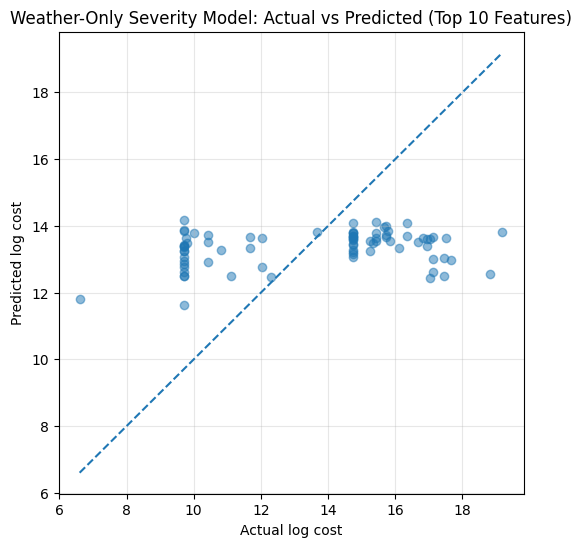

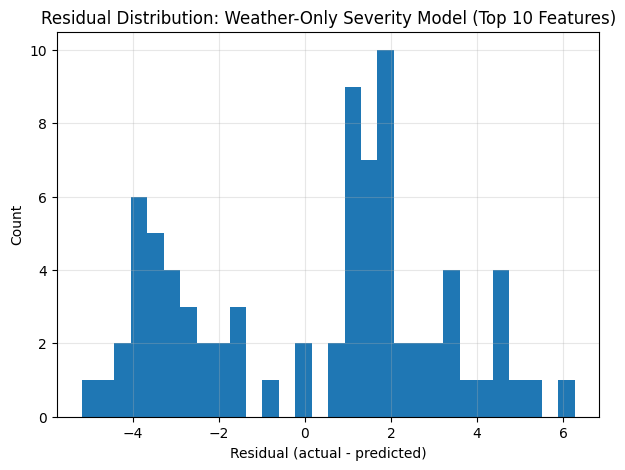

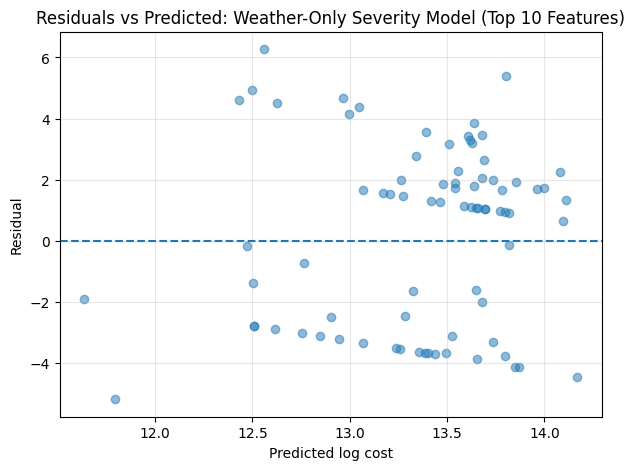

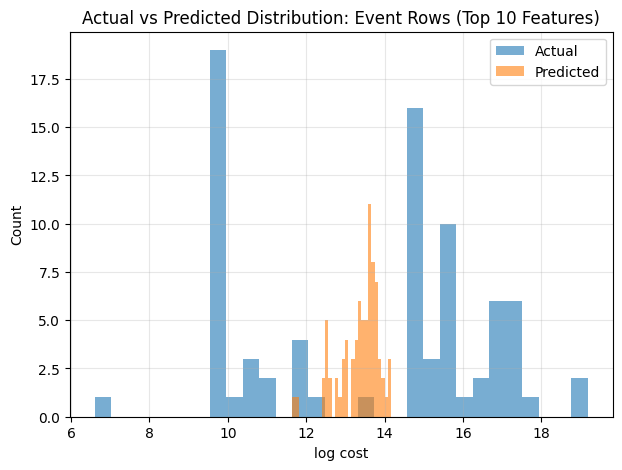

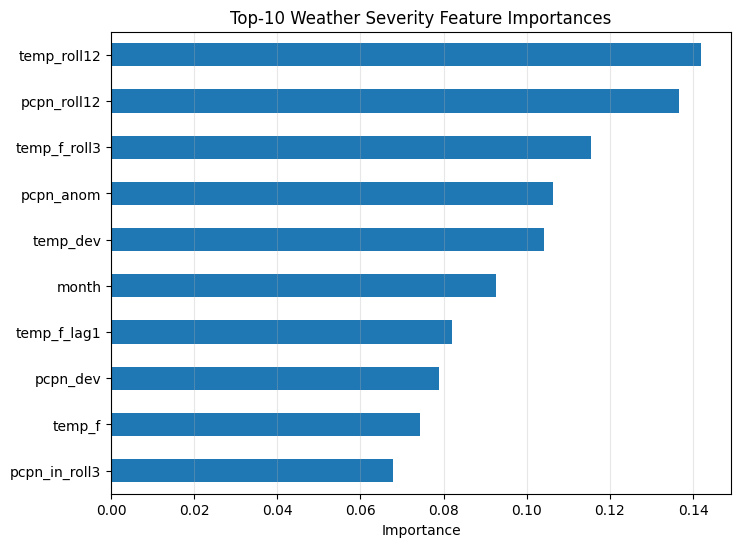

Top severity features:
temp_roll12      0.141997
pcpn_roll12      0.136495
temp_f_roll3     0.115326
pcpn_anom        0.106199
temp_dev         0.104229
month            0.092700
temp_f_lag1      0.082089
pcpn_dev         0.078826
temp_f           0.074405
pcpn_in_roll3    0.067734
dtype: float32
Baseline vs model
Baseline MAE: 2.766400735887035
Model MAE: 2.613244506318646
Baseline RMSE: 3.022832613211311
Model RMSE: 2.9299239043754537


In [8]:
# -----------------------------
# 10. Additional metrics + visuals for top-10 weather severity model
# -----------------------------
pearson_corr = pearsonr(y_test_reg_events, event_only_preds)[0]
spearman_corr = spearmanr(y_test_reg_events, event_only_preds)[0]
residuals = y_test_reg_events - event_only_preds

print("===== Additional Severity Diagnostics (TOP 10 FEATURES) =====")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Prediction std:", np.std(event_only_preds))
print("Actual std:", np.std(y_test_reg_events))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg_events, event_only_preds, alpha=0.5)
mn = min(y_test_reg_events.min(), event_only_preds.min())
mx = max(y_test_reg_events.max(), event_only_preds.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual log cost")
plt.ylabel("Predicted log cost")
plt.title("Weather-Only Severity Model: Actual vs Predicted (Top 10 Features)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution: Weather-Only Severity Model (Top 10 Features)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(event_only_preds, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log cost")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted: Weather-Only Severity Model (Top 10 Features)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(y_test_reg_events, bins=30, alpha=0.6, label="Actual")
plt.hist(event_only_preds, bins=30, alpha=0.6, label="Predicted")
plt.xlabel("log cost")
plt.ylabel("Count")
plt.title("Actual vs Predicted Distribution: Event Rows (Top 10 Features)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

reg_importances = pd.Series(best_reg.feature_importances_, index=top_features).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
reg_importances.sort_values().plot(kind="barh")
plt.title("Top-10 Weather Severity Feature Importances")
plt.xlabel("Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

print("Top severity features:")
print(reg_importances)

baseline_residuals = y_test_reg_events - event_mean_pred
print("Baseline vs model")
print("Baseline MAE:", mean_absolute_error(y_test_reg_events, event_mean_pred))
print("Model MAE:", mean_absolute_error(y_test_reg_events, event_only_preds))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test_reg_events, event_mean_pred)))
print("Model RMSE:", np.sqrt(mean_squared_error(y_test_reg_events, event_only_preds)))


In [7]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,5))

for label, probs in [
    ("Weather Only", weather_probs),
    ("State + History", state_hist_probs),
    ("Full Model", full_probs),
]:
    precision, recall, _ = precision_recall_curve(y_test_cls, probs)
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NameError: name 'weather_probs' is not defined

<Figure size 700x500 with 0 Axes>